<a href="https://colab.research.google.com/github/HamzaEric/Advanced_Python/blob/main/Notebooks/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

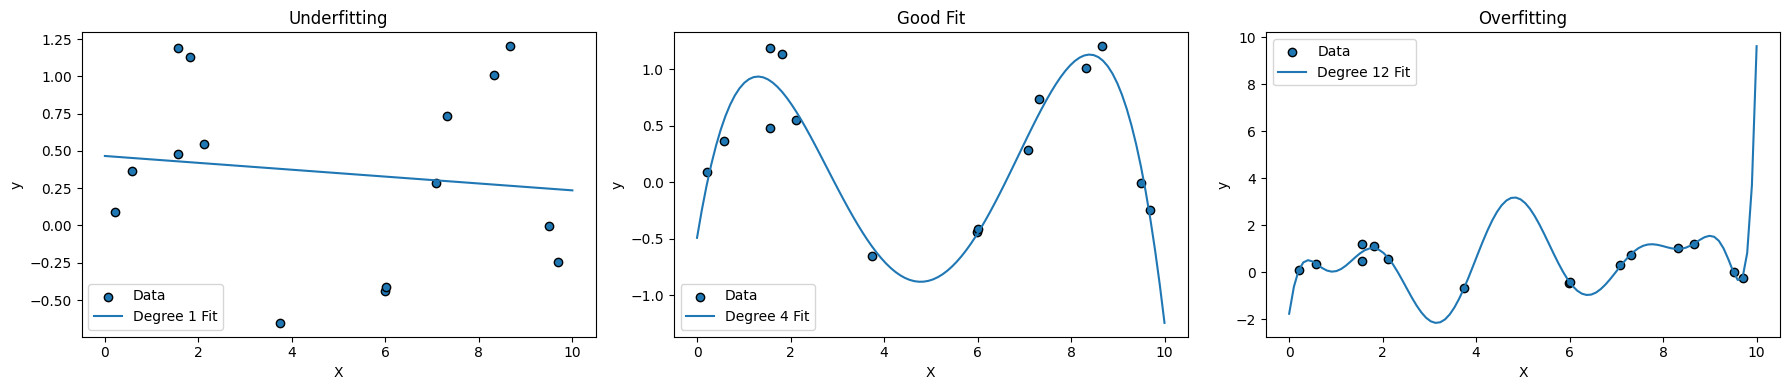

In [2]:
np.random.seed(42)
X = np.sort(np.random.rand(15, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# Define models with different complexity
degrees = [1, 4, 12]
x_plot = np.linspace(0, 10, 100).reshape(-1, 1)

plt.figure(figsize=(18, 4))

for i, d in enumerate(degrees):
    plt.subplot(1, 3, i + 1)
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X, y)
    y_plot = model.predict(x_plot)

    plt.scatter(X, y, edgecolor='k', label="Data")
    plt.plot(x_plot, y_plot, label=f"Degree {d} Fit")
    plt.title(["Underfitting", "Good Fit", "Overfitting"][i])
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()


>What This Visualization Shows:

- **Left (Degree 1)**: The model is too simple — it fails to follow the curved shape of the data and misses key trends. This is an example of **underfitting**, where the model is not flexible enough.
  
- **Middle (Degree 4)**: The model fits the underlying trend while smoothing out noise. This is an example of a **well-generalized model** — good training fit and expected strong performance on new data.
  
- **Right (Degree 12)**: The model bends sharply between data points and fits the noise. While training error may be low, test performance would be poor — a clear case of **overfitting**.

>Why This Matters for Neural Networks

Neural networks are powerful because:
- They can model **non-linear patterns** using layers and activations.
- But they also have **millions of parameters** in larger setups.

This flexibility means:
- Without checks, neural networks may memorize the training set.
- This leads to high training accuracy, but poor test generalization — i.e., **overfitting**.

# Data Preparation

 **Split** the dataset into:
   - **Training set** → what the model actually learns from
   - **Validation set** → used to tune settings and monitor overfitting
   - **Test set** → a locked box used only for final evaluation

# Hyperparameters

- Hyperparameters are the **“settings” we choose before training begins**, like:
  - Number of hidden units
  - Learning rate
  - Dropout probability
  - Batch size
- These are **not learned by the model** — we choose them manually (or via tuning), and the **validation set helps us judge which choices work best**.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/yeast.csv")
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [4]:
X = df.drop(columns=["localization_site"])
y = df["localization_site"]

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
num_classes = len(class_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# First split: Train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# Second split: Val vs Test (from temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [7]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Confirm shapes
print(f"Train set: {X_train_tensor.shape}")
print(f"Validation set: {X_val_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}")
print(f"Number of Classes: {num_classes}")
print(f"Class Names: {class_names}")

Train set: torch.Size([1038, 8])
Validation set: torch.Size([223, 8])
Test set: torch.Size([223, 8])
Number of Classes: 10
Class Names: ['CYT' 'ERL' 'EXC' 'ME1' 'ME2' 'ME3' 'MIT' 'NUC' 'POX' 'VAC']


In [8]:
CT_unique_classes, CT_class_counts = torch.unique(y_train_tensor, return_counts=True)

print("CT_Class Distribution:")

for i, c in zip(CT_unique_classes, CT_class_counts):
    print(f"{class_names[i.item()]}: {c.item()}")

CT_Class Distribution:
CYT: 324
ERL: 3
EXC: 24
ME1: 31
ME2: 36
ME3: 114
MIT: 171
NUC: 300
POX: 14
VAC: 21


# Baseline Model — No Regularization
>Model Design

- **Input layer**: 8 features
- **Hidden layer**: 32 neurons + ReLU
- **Output layer**: 10 neurons (for 10 classes)

We'll use this model as a **baseline** to compare future regularized versions.


In [9]:
# Define the model
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(BaselineMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Instantiate model
input_dim = X_train_tensor.shape[1]
hidden_dim = 32
output_dim = num_classes

model_base = BaselineMLP(input_dim, hidden_dim, output_dim)
print(model_base)

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_base.parameters(), lr=0.01)

# Store loss values
train_losses_base = []
val_losses_base = []

# Training loop
epochs = 1000
for epoch in range(epochs):
    # Training phase
    model_base.train()
    optimizer.zero_grad()
    outputs = model_base(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses_base.append(loss.item())

    # Validation phase
    model_base.eval()
    with torch.no_grad():
        val_outputs = model_base(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses_base.append(val_loss.item())


    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")


Epoch 50: Train Loss = 1.0251, Val Loss = 1.1297
Epoch 100: Train Loss = 0.9452, Val Loss = 1.1167
Epoch 150: Train Loss = 0.9002, Val Loss = 1.1296
Epoch 200: Train Loss = 0.8645, Val Loss = 1.1523
Epoch 250: Train Loss = 0.8265, Val Loss = 1.1925
Epoch 300: Train Loss = 0.7902, Val Loss = 1.2506
Epoch 350: Train Loss = 0.7567, Val Loss = 1.2973
Epoch 400: Train Loss = 0.7335, Val Loss = 1.3526
Epoch 450: Train Loss = 0.7136, Val Loss = 1.4182
Epoch 500: Train Loss = 0.6956, Val Loss = 1.4729
Epoch 550: Train Loss = 0.6829, Val Loss = 1.5330
Epoch 600: Train Loss = 0.6749, Val Loss = 1.5886
Epoch 650: Train Loss = 0.6658, Val Loss = 1.6446
Epoch 700: Train Loss = 0.6601, Val Loss = 1.6997
Epoch 750: Train Loss = 0.6522, Val Loss = 1.7424
Epoch 800: Train Loss = 0.6459, Val Loss = 1.7815
Epoch 850: Train Loss = 0.6411, Val Loss = 1.8129
Epoch 900: Train Loss = 0.6367, Val Loss = 1.8374
Epoch 950: Train Loss = 0.6299, Val Loss = 1.8608
Epoch 1000: Train Loss = 0.6250, Val Loss = 1.9076


# **Plotting Loss Curves**

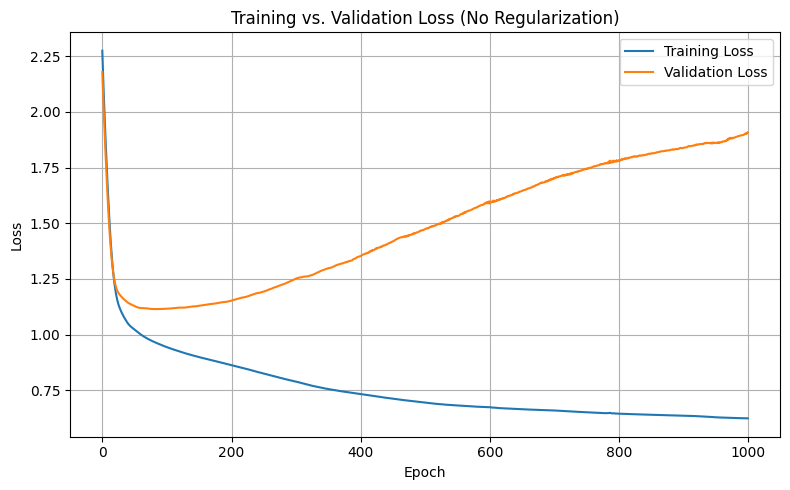

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_base, label="Training Loss")
plt.plot(val_losses_base, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss (No Regularization)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Model Insights**

- The **training loss** continues to drop, indicating the model is fitting the training data increasingly well.
- However, the **validation loss** begins to **rise noticeably after ~100 epochs**, showing that generalization is deteriorating.
- This widening gap between training and validation performance is a strong indicator of **overfitting**.

> Clear Overfitting Observed

This behavior signals that:

- The model is either **too flexible** or **too powerful** for the dataset,
- Without regularization, it starts to memorize the specific values -- patterns and noise -- in the training data,
- This results in poor performance on unseen validation data.

This is a **classic deep learning pitfall**. Left unchecked, overfitting can severely hinder a model's usefulness in the real world.

# Regularization

**Regularization** refers to a set of techniques we use to **prevent overfitting** and help the model **generalize better to unseen data**.

Think of it as a way to **discourage the model from becoming too confident or too complex** — like asking it to stay humble and avoid “memorizing” the training set too perfectly.

In practice, regularization works by:
- Adding a small **penalty** for complexity (e.g., very large weights),
- Forcing the model to **rely on multiple pathways** instead of fixating on just a few neurons,
- Helping the model remain **flexible but not overly sensitive** to training noise.

# Methods Used
 - **Dropout** — randomly “turns off” parts of the network during training.
 - **L2 Regularization (Weight Decay)** — discourages overly large weights by adding a penalty term.

Both techniques aim to make the model **more robust and fair**, especially when dealing with imbalanced or noisy datasets.

In [14]:
CT_final_train_loss = train_losses_base[-1]
CT_final_val_loss = val_losses_base[-1]  # Use test_losses[-1] if that's what you named it in your loop

print(f"CT_Baseline Final Train Loss: {CT_final_train_loss:.4f}")
print(f"CT_Baseline Final Val Loss: {CT_final_val_loss:.4f}")

CT_Baseline Final Train Loss: 0.6250
CT_Baseline Final Val Loss: 2.0959


# Dropout Regularization



In [15]:
class MLPWithDropout(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_prob=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),  # 🔽 Dropout added here
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


model_dropout = MLPWithDropout(input_dim, hidden_dim, output_dim, dropout_prob=0.5)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropout.parameters(), lr=0.01)


train_losses_dropout = []
val_losses_dropout = []


epochs = 1000
for epoch in range(epochs):
    # Training
    model_dropout.train()
    optimizer.zero_grad()
    outputs = model_dropout(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses_dropout.append(loss.item())

    # Validation
    model_dropout.eval()
    with torch.no_grad():
        val_outputs = model_dropout(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses_dropout.append(val_loss.item())

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

Epoch 50: Train Loss = 1.1676, Val Loss = 1.1360
Epoch 100: Train Loss = 1.1383, Val Loss = 1.1109
Epoch 150: Train Loss = 1.1058, Val Loss = 1.1029
Epoch 200: Train Loss = 1.0868, Val Loss = 1.0970
Epoch 250: Train Loss = 1.1037, Val Loss = 1.0948
Epoch 300: Train Loss = 1.0776, Val Loss = 1.0942
Epoch 350: Train Loss = 1.0834, Val Loss = 1.0966
Epoch 400: Train Loss = 1.0752, Val Loss = 1.0963
Epoch 450: Train Loss = 1.0521, Val Loss = 1.0978
Epoch 500: Train Loss = 1.0520, Val Loss = 1.0920
Epoch 550: Train Loss = 1.0441, Val Loss = 1.1062
Epoch 600: Train Loss = 1.0348, Val Loss = 1.1143
Epoch 650: Train Loss = 1.0379, Val Loss = 1.1175
Epoch 700: Train Loss = 1.0562, Val Loss = 1.1139
Epoch 750: Train Loss = 1.0434, Val Loss = 1.1267
Epoch 800: Train Loss = 1.0183, Val Loss = 1.1290
Epoch 850: Train Loss = 1.0300, Val Loss = 1.1191
Epoch 900: Train Loss = 1.0425, Val Loss = 1.1264
Epoch 950: Train Loss = 1.0250, Val Loss = 1.1307
Epoch 1000: Train Loss = 1.0332, Val Loss = 1.1427


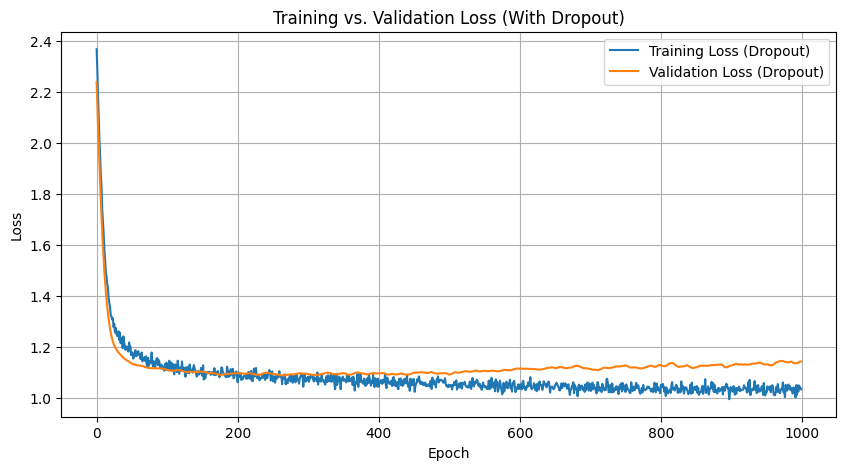

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses_dropout, label='Training Loss (Dropout)')
plt.plot(val_losses_dropout, label='Validation Loss (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss (With Dropout)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
model_dropout.eval()
with torch.no_grad():

    CT_logits = model_dropout(X_test_tensor)
    CT_preds = torch.argmax(CT_logits, dim=1)


CT_y_val_np = y_test_tensor.numpy()
CT_y_pred_np = CT_preds.numpy()

CT_val_acc = accuracy_score(CT_y_val_np, CT_y_pred_np)
CT_val_f1 = f1_score(CT_y_val_np, CT_y_pred_np, average="macro")

print(f"CT_Val Accuracy (Dropout): {CT_val_acc:.4f}")
print(f"CT_Val Macro F1 (Dropout): {CT_val_f1:.4f}")

CT_Val Accuracy (Dropout): 0.6233
CT_Val Macro F1 (Dropout): 0.6026


# L2 Regularization

L2 Regularization (Ridge / Weight Decay): Penalizes the squared magnitude of the weights ($w_i^2$).

This pushes all weights to become very small, but rarely exactly zero. It acts like a rubber band, distributing the network's reliance smoothly across all features so no single weight dominates.

> How L2 Regularization Works (Intuition)

L2 regularization (also called **weight decay**) discourages the model from using **very large weights** by adding a small penalty term to the loss function:

$$
\text{New Loss} = \text{CrossEntropy} + \lambda \cdot \sum w^2
$$

$$
J(\theta)
=
J_{\text{CE}}(\theta)
+
\lambda \sum_j w_j^2
$$

- $J(\theta)$ = total loss
- $J_{\text{CE}}(\theta)$ = cross-entropy loss
- $\lambda$ = regularization strength
- $w_j$ = model weights
- $\sum_j w_j^2$ = L2 regularization penalty

In [18]:
class MLP_L2(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP_L2, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)


model_l2 = MLP_L2(input_dim=8, hidden_dim=64, output_dim=10)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=0.0001)


epochs = 1000
train_losses_l2 = []
val_losses_l2 = []

for epoch in range(epochs):
    model_l2.train()
    outputs = model_l2(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    train_losses_l2.append(loss.item())

    model_l2.eval()
    with torch.no_grad():
        val_outputs = model_l2(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses_l2.append(val_loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

Epoch 50: Train Loss = 1.6865, Val Loss = 1.6928
Epoch 100: Train Loss = 1.2996, Val Loss = 1.3412
Epoch 150: Train Loss = 1.1481, Val Loss = 1.2175
Epoch 200: Train Loss = 1.0801, Val Loss = 1.1687
Epoch 250: Train Loss = 1.0390, Val Loss = 1.1449
Epoch 300: Train Loss = 1.0094, Val Loss = 1.1320
Epoch 350: Train Loss = 0.9858, Val Loss = 1.1243
Epoch 400: Train Loss = 0.9668, Val Loss = 1.1198
Epoch 450: Train Loss = 0.9517, Val Loss = 1.1170
Epoch 500: Train Loss = 0.9383, Val Loss = 1.1155
Epoch 550: Train Loss = 0.9265, Val Loss = 1.1140
Epoch 600: Train Loss = 0.9155, Val Loss = 1.1149
Epoch 650: Train Loss = 0.9056, Val Loss = 1.1156
Epoch 700: Train Loss = 0.8961, Val Loss = 1.1163
Epoch 750: Train Loss = 0.8871, Val Loss = 1.1160
Epoch 800: Train Loss = 0.8780, Val Loss = 1.1151
Epoch 850: Train Loss = 0.8694, Val Loss = 1.1146
Epoch 900: Train Loss = 0.8611, Val Loss = 1.1162
Epoch 950: Train Loss = 0.8527, Val Loss = 1.1175
Epoch 1000: Train Loss = 0.8441, Val Loss = 1.1218


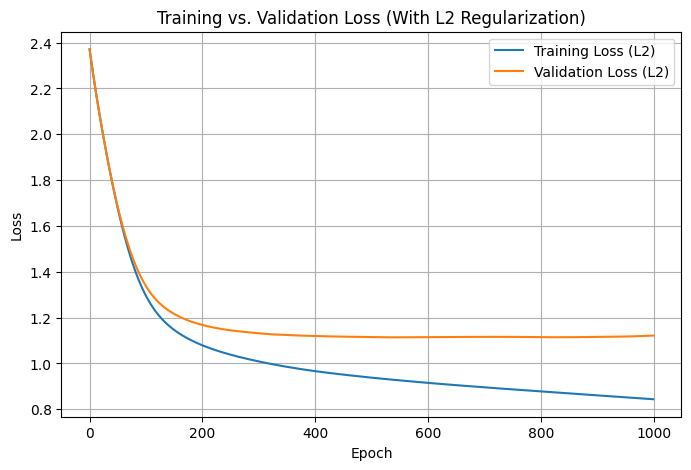

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_l2, label="Training Loss (L2)")
plt.plot(val_losses_l2, label="Validation Loss (L2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss (With L2 Regularization)")
plt.legend()
plt.grid(True)
plt.show()

This plot shows how adding **L2 regularization (weight decay)** changes the training dynamics.

> What We Observe:

- **Training loss** continues to decline steadily, though slightly slower than in the no-regularization case.
- **Validation loss** initially drops, then begins to **flatten out and rise slightly** around epoch 700.
- Compared to the baseline, the model **overfits later and more gradually**.

>  What This Suggests:

- L2 regularization helped **delay the onset of overfitting** — by gently constraining the model’s capacity.
- However, since we haven’t used any additional regularization (like dropout or early stopping), **some overfitting still occurs**.
- The **gap between training and validation loss is narrower** than in the baseline, suggesting improved **generalization**.



# Weight decay applied during the update

Instead of adding the penalty to the loss, the optimizer can directly shrink the weights during the update.

Conceptually:

$$ w_{\text{new}} = w-\eta\nabla_w L -\eta\lambda w $$

The extra term

$$ -\eta\lambda w $$

pushes the weights toward zero.

That's weight decay.

In [20]:
CT_l2_val_loss = val_losses_l2[-1]
CT_dropout_val_loss = val_losses_l2[-1]

print(f"CT_Final Val Loss (L2): {CT_l2_val_loss:.4f}")
print(f"CT_Final Val Loss (Dropout): {CT_dropout_val_loss:.4f}")

CT_Final Val Loss (L2): 1.1218
CT_Final Val Loss (Dropout): 1.1218


In [21]:
CT_l2_val_loss = val_losses_l2[-1]
CT_dropout_val_loss = val_losses_dropout[-1]

print(f"CT_Final Val Loss (L2): {CT_l2_val_loss:.4f}")
print(f"CT_Final Val Loss (Dropout): {CT_dropout_val_loss:.4f}")

CT_Final Val Loss (L2): 1.1218
CT_Final Val Loss (Dropout): 1.1427


# **Combine Dropout + L2 Regularization**



In [22]:
class MLP_Dropout_L2(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.5):
        super(MLP_Dropout_L2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [23]:
model_dropout_l2 = MLP_Dropout_L2(input_dim, hidden_dim=32, output_dim=num_classes, dropout_rate=0.5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dropout_l2.parameters(), lr=0.001, weight_decay=1e-4)

train_losses_dropout_L2 = []
val_losses_dropout_L2 = []

for epoch in range(1000):
    model_dropout_l2.train()
    y_pred = model_dropout_l2(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    train_losses_dropout_L2.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_dropout_l2.eval()
    with torch.no_grad():
        val_output = model_dropout_l2(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)
        val_losses_dropout_L2.append(val_loss.item())

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

Epoch 50: Train Loss = 1.9541, Val Loss = 1.9137
Epoch 100: Train Loss = 1.6313, Val Loss = 1.5887
Epoch 150: Train Loss = 1.4386, Val Loss = 1.3849
Epoch 200: Train Loss = 1.3241, Val Loss = 1.2753
Epoch 250: Train Loss = 1.2421, Val Loss = 1.2196
Epoch 300: Train Loss = 1.2210, Val Loss = 1.1877
Epoch 350: Train Loss = 1.2090, Val Loss = 1.1681
Epoch 400: Train Loss = 1.2069, Val Loss = 1.1551
Epoch 450: Train Loss = 1.1700, Val Loss = 1.1470
Epoch 500: Train Loss = 1.1745, Val Loss = 1.1405
Epoch 550: Train Loss = 1.1695, Val Loss = 1.1367
Epoch 600: Train Loss = 1.1370, Val Loss = 1.1337
Epoch 650: Train Loss = 1.1108, Val Loss = 1.1325
Epoch 700: Train Loss = 1.1255, Val Loss = 1.1308
Epoch 750: Train Loss = 1.1507, Val Loss = 1.1294
Epoch 800: Train Loss = 1.1064, Val Loss = 1.1263
Epoch 850: Train Loss = 1.1101, Val Loss = 1.1246
Epoch 900: Train Loss = 1.1270, Val Loss = 1.1224
Epoch 950: Train Loss = 1.1159, Val Loss = 1.1209
Epoch 1000: Train Loss = 1.1224, Val Loss = 1.1200


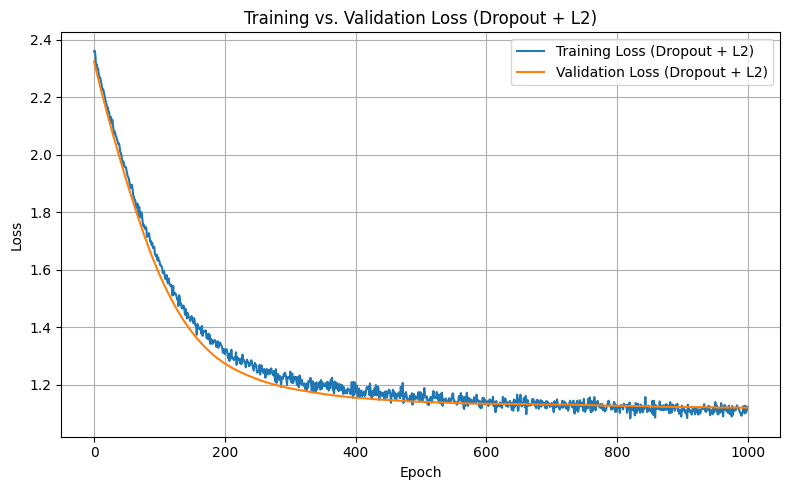

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_dropout_L2, label="Training Loss (Dropout + L2)")
plt.plot(val_losses_dropout_L2, label="Validation Loss (Dropout + L2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss (Dropout + L2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Training and validation curves show **better alignment**, indicating improved generalization.
- The curve is smoother compared to Dropout or L2 alone.
- No extreme overfitting is observed.

The combination of **Dropout + L2** regularization provides a solid balance of learning flexibility and generalization — especially useful for smaller or noisy datasets.

# **Visual Comparison of Regularization Strategies**

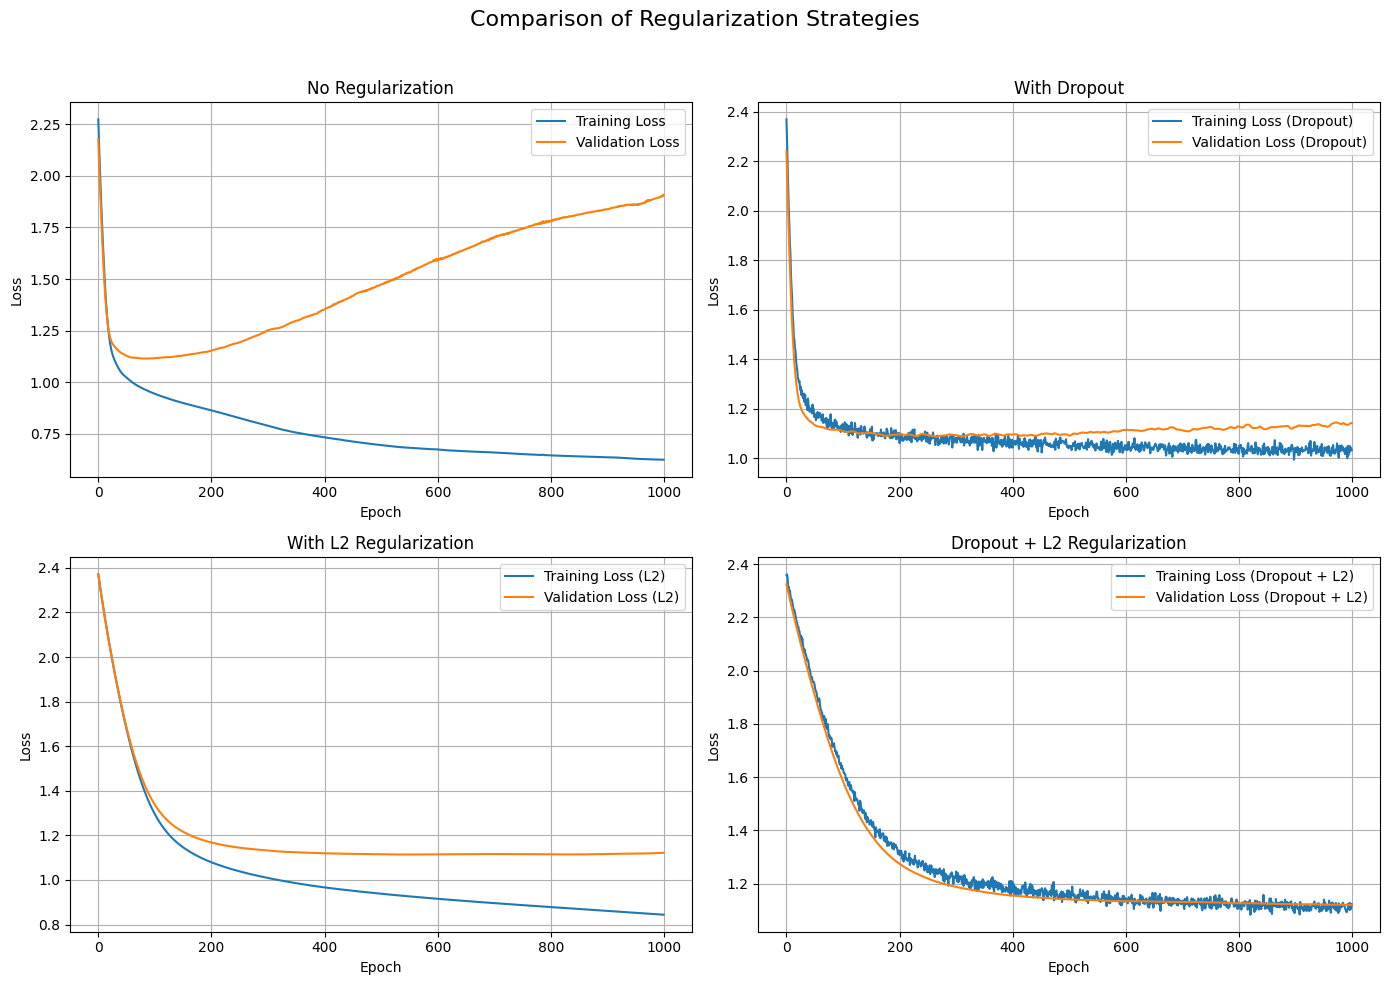

In [25]:
# Create 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: No Regularization
axs[0, 0].plot(train_losses_base, label="Training Loss")
axs[0, 0].plot(val_losses_base, label="Validation Loss")
axs[0, 0].set_title("No Regularization")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Plot 2: Dropout
axs[0, 1].plot(train_losses_dropout, label="Training Loss (Dropout)")
axs[0, 1].plot(val_losses_dropout, label="Validation Loss (Dropout)")
axs[0, 1].set_title("With Dropout")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Plot 3: L2 Regularization
axs[1, 0].plot(train_losses_l2, label="Training Loss (L2)")
axs[1, 0].plot(val_losses_l2, label="Validation Loss (L2)")
axs[1, 0].set_title("With L2 Regularization")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Loss")
axs[1, 0].legend()
axs[1, 0].grid(True)

# Plot 4: Dropout + L2
axs[1, 1].plot(train_losses_dropout_L2, label="Training Loss (Dropout + L2)")
axs[1, 1].plot(val_losses_dropout_L2, label="Validation Loss (Dropout + L2)")
axs[1, 1].set_title("Dropout + L2 Regularization")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Loss")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Final layout adjustments
plt.suptitle("Comparison of Regularization Strategies", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


> In summary

- **M1** (No Reg): Shows classic overfitting — loss drops early but then rises.
- **M2** (Dropout): Stabilizes training but may still fluctuate.
- **M3** (L2): Slower but more consistent convergence.
- **M4** (Dropout + L2): Best trade-off — smooth curve and generalizes well.

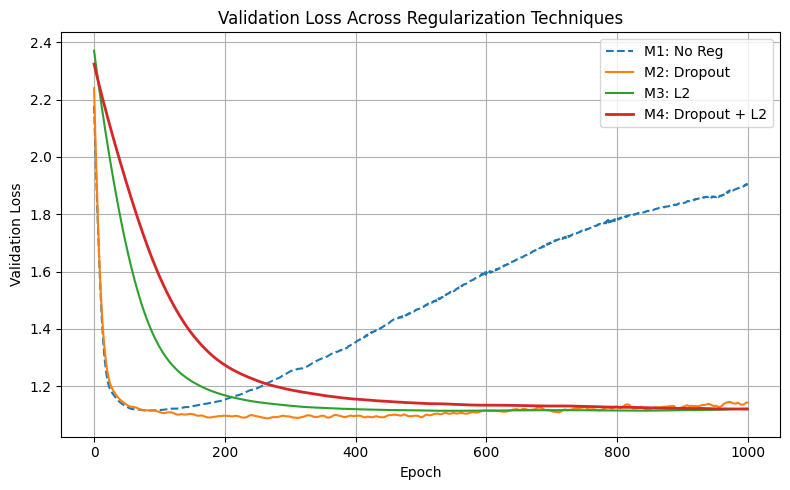

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(val_losses_base, label='M1: No Reg', linestyle='--')
plt.plot(val_losses_dropout, label='M2: Dropout')
plt.plot(val_losses_l2, label='M3: L2')
plt.plot(val_losses_dropout_L2, label='M4: Dropout + L2', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Across Regularization Techniques")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        preds = torch.argmax(logits, dim=1)

    y_true = y_test_tensor.cpu().numpy()
    y_pred = preds.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, f1

# Evaluate No Regularization (M1)
acc_m1, f1_m1 = evaluate_model(model_base, X_test_tensor, y_test_tensor)

# Evaluate Dropout Only (M2)
acc_m2, f1_m2 = evaluate_model(model_dropout, X_test_tensor, y_test_tensor)

# Evaluate L2 Regularization Only (M3)
acc_m3, f1_m3 = evaluate_model(model_l2, X_test_tensor, y_test_tensor)

# Evaluate Dropout + L2 (M4)
acc_m4, f1_m4 = evaluate_model(model_dropout_l2, X_test_tensor, y_test_tensor)

results = {
    "Model": ["No Reg (M1)", "Dropout (M2)", "L2 (M3)", "Dropout + L2 (M4)"],
    "Test Accuracy": [acc_m1, acc_m2, acc_m3, acc_m4],
    "Macro F1 Score": [f1_m1, f1_m2, f1_m3, f1_m4]
}

results_df = pd.DataFrame(results)
print(results_df)

               Model  Test Accuracy  Macro F1 Score
0        No Reg (M1)       0.573991        0.553827
1       Dropout (M2)       0.623318        0.602558
2            L2 (M3)       0.596413        0.592750
3  Dropout + L2 (M4)       0.582960        0.444720
